# 017 — Disaggregation IMLs for MSA stripes

Choose, for each site and each intensity measure (**AvgSA(0-3 s)** and **AvgSA(0-6 s)**),
the IMLs that (a) OpenQuake disaggregates at — the flat IML grid used by nb 020/021 — and
(b) define the per-site record-selection stripes used by nb 031-036.

For every site an interpolated collapse fragility is built from the reference-structure
fragilities (nb 013) blended over design strength `Vb_coeff`. From a candidate IML grid we
pick the (up to) 4 IMLs that best bracket the body of that fragility (targeting
P[C] = 0.15 / 0.4 / 0.6 / 0.85), keeping only IMLs at or below the PSHA truncation ceiling.
The selection is compared across truncation levels (3/4/5σ) so the working σ can be
confirmed.

## Upstream / downstream

**Upstream** (all must have been run):

- `004-psha_results` → AvgSA(0-3 s) & AvgSA(0-6 s) hazard curves at 3/4/5σ
  (`cfg["proc_data"]["AvgSA_0{3,6}_hazard_curves_{3,4,5}sig"]`)
- `010_cbfs_reference_designs_ec8_gen2_and_analyses` → reference design dataset
  (`cfg["proc_data"]["dc2_scA_reference_dataset"]`) **and** its FEMA-P695 reference IDAs,
  which must have been run so `013` can convert the collapse fragilities. Launch via
  `phd_project/scripts/WP1_ground_motion_set/batch_run_analyses/ec8_gen2_reference_structures/3s/mdof/ida.py`
  (results land in each `<tag>/mdof/ida_femap695/`).
- `011-create_site_casestudies_and_analyses` → `site_designs_summary.csv`
  (`cfg["models"]["site_specific_designs_summary"]`)
- `013-convert_reference_fragilities_to_avgsa` → reference collapse fragilities in AvgSA
  (`cfg["proc_data"]["dc2_scA_reference_collapse_fc_summary"]`)

**Downstream:**

- the flat IML grids (`disagg_imls_AvgSA_0{3,6}`) feed `020-disaggregation` / `021-…`
- the per-site stripes (`AvgSA_0{3,6}_imls_for_selection`) feed record selection
  (`031`–`036`) via `setup_AvgSA0{3,6}_gm_selection.py`

> Exploratory AvgSA sanity checks and the site-MAFC estimate were moved to
> `archived/017a-disagg_imls_sanity_and_site_mafc.ipynb`.

## 0. Setup & parameters

In [164]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [165]:
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from scipy.stats import lognorm
from scipy.optimize import linear_sum_assignment

from phd_project.config import config

cfg = config.load_config()

In [166]:
# ----------------------------------------------------------------------------
# PARAMETERS
# ----------------------------------------------------------------------------
# Intensity measures handled in this notebook.
IMS = ("AvgSA_03", "AvgSA_06")

# Candidate IML grid for the iml-based disaggregation, one per IM. These are the IMLs
# OpenQuake disaggregates at (nb 020); the per-site record-selection stripes (nb 031-036)
# are drawn from this grid. Chosen by inspection so that >=4 grid points land on the body
# of every site's collapse fragility.
IMLS_AVGSA_03 = np.array([0.285, 0.310, 0.330, 0.360, 0.400, 0.450, 0.550, 0.650, 0.800, 0.950, 1.150])
IMLS_AVGSA_06 = np.array([0.100, 0.130, 0.180, 0.220, 0.280, 0.330, 0.400, 0.480, 0.550, 0.620, 0.700])
IMLS = {"AvgSA_03": IMLS_AVGSA_03, "AvgSA_06": IMLS_AVGSA_06}

# Fragility-fit conditioning: with 30 records per stripe a binomial-MLE collapse fit is
# well conditioned when the observed collapse count is within [LO, HI].
N_RECORDS = 30
LO, HI = 3, 27

# Target collapse probabilities the (up to) 4 disaggregation IMLs should bracket.
TARGET_PCS = [0.15, 0.4, 0.6, 0.85]

# PSHA truncation (epsilon) levels to compare. The hazard ceiling (max usable IML) grows
# with the truncation level; DISAGG_SIGMA is the level whose per-site selection is written
# to the output files in section 5.
TRUNC_LEVELS = (3, 4, 5)
DISAGG_SIGMA = 4

# Fine IML grid (g) used to draw the interpolated site collapse curves.
IML_GRID = np.logspace(np.log10(0.01), np.log10(3.0), 300)  # g

# Site groups for plotting (low-moderate vs high seismicity).
GROUPS = [
    (range(0, 30), "Sites 0-29  (low-moderate seismicity)"),
    (range(30, 60), "Sites 30-59  (high seismicity)"),
]

## 1. Load hazard, designs & fragilities

Everything is loaded from `config.yaml` keys. Hazard curves come from nb 004 in the flat
structure `hcs[site_id]["AvgSA"][stat] -> ndarray (n_iml, 2)` (col 0 = IML [g], col 1 =
MAFE), one file per (IM, truncation level). Reference designs come from nb 010 and carry
`Vb_coeff` as a column (no recompute); the site-specific `Vb_coeff` comes from nb 011's
summary CSV (its `site_id` is derived from the `tag`). Reference collapse fragilities in
AvgSA come from nb 013's summary CSV, whose medians are already in **g**.

In [167]:
def load_hazard(im):
    """Mean hazard curve per truncation level for one IM.

    Returns curves[level][site] -> ndarray (n_iml, 2), col 0 = IML [g], col 1 = MAFE.
    All six nb-004 pickles share the flat hcs[site]["AvgSA"][stat] structure.
    """
    curves = {}
    for sig, level in (("3sig", 3), ("4sig", 4), ("5sig", 5)):
        with open(cfg["proc_data"][f"{im}_hazard_curves_{sig}"], "rb") as f:
            raw = pickle.load(f)
        curves[level] = {site: raw[site]["AvgSA"]["mean"] for site in sorted(raw)}
    return curves


hazard = {im: load_hazard(im) for im in IMS}
sites = sorted(hazard["AvgSA_03"][3])
print(f"loaded hazard for {len(sites)} sites, IMs {list(hazard)}, truncation levels {TRUNC_LEVELS}")

loaded hazard for 60 sites, IMs ['AvgSA_03', 'AvgSA_06'], truncation levels (3, 4, 5)


In [168]:
# Reference (site-independent) designs from nb 010: `name` and `Vb_coeff` are plain columns.
reference_designs = pd.read_pickle(cfg["proc_data"]["dc2_scA_reference_dataset"])
reference_designs = reference_designs[reference_designs["name"].str.startswith("3s_")].copy()

# Site-specific designs from nb 011. The CSV has no explicit site_id column, so derive the
# integer site id from the tag (e.g. "3s_cbf_dc2_site7" -> 7).
sitespec_designs = pd.read_csv(cfg["models"]["site_specific_designs_summary"])
sitespec_designs["site_id"] = sitespec_designs["tag"].str.split("site").str[-1].astype(int)
site_vb = sitespec_designs.set_index("site_id")["Vb_coeff"].sort_index()

# Reference collapse fragilities in AvgSA (nb 013). Two-level columns (IM -> median/dispersion);
# medians are already in g.
fc_summary = pd.read_csv(
    cfg["proc_data"]["dc2_scA_reference_collapse_fc_summary"], header=[0, 1], index_col=0
)
fc_summary

IM                    SA             AvgSA_03             AvgSA_06           
parameter         median dispersion    median dispersion    median dispersion
structure                                                                    
3s_dc2_scA_13   0.985487   0.406044  0.393142   0.216237  0.177779   0.254886
3s_dc2_scA_20   0.985487   0.406044  0.393142   0.216237  0.177779   0.254886
3s_dc2_scA_30   0.941296   0.421550  0.356276   0.180760  0.161108   0.278448
3s_dc2_scA_40   1.442773   0.536756  0.466230   0.190812  0.210830   0.327330
3s_dc2_scA_50   1.325881   0.527436  0.419701   0.175810  0.189789   0.327218
3s_dc2_scA_60   1.394596   0.525751  0.433242   0.177688  0.195912   0.330271
3s_dc2_scA_70   1.944080   0.396273  0.587380   0.225877  0.265614   0.388994
3s_dc2_scA_100  2.625250   0.332585  0.767048   0.263936  0.346860   0.417027
3s_dc2_scA_120  3.172556   0.346549  0.931035   0.283062  0.421015   0.425240

## 2. Reference collapse fragilities

For each IM assemble the reference collapse ladder — design strength `Vb_coeff` (from the
nb 010 dataset) joined to the AvgSA collapse fragility (median [g] + lognormal dispersion
from nb 013) — sorted ascending in `Vb_coeff` so it can be interpolated over strength.

In [169]:
vb_ref_lookup = reference_designs.set_index("name")["Vb_coeff"]


def build_refs(im):
    """Reference collapse ladder for one IM, sorted ascending in Vb_coeff."""
    refs = pd.DataFrame(
        [
            {
                "name": name,
                "Vb_coeff": float(vb_ref_lookup[name]),
                "median": float(fc_summary.loc[name, (im, "median")]),        # g
                "dispersion": float(fc_summary.loc[name, (im, "dispersion")]),
            }
            for name in fc_summary.index
        ]
    ).sort_values("Vb_coeff", ignore_index=True)
    assert refs["Vb_coeff"].is_monotonic_increasing
    return refs


refs_by_im = {im: build_refs(im) for im in IMS}
refs_by_im["AvgSA_03"]

,name,Vb_coeff,median,dispersion
0,3s_dc2_scA_13,0.026098,0.393142,0.216237
1,3s_dc2_scA_20,0.027234,0.393142,0.216237
2,3s_dc2_scA_30,0.043757,0.356276,0.180760
3,3s_dc2_scA_40,0.086012,0.466230,0.190812
4,3s_dc2_scA_50,0.114445,0.419701,0.175810
5,3s_dc2_scA_60,0.140632,0.433242,0.177688
6,3s_dc2_scA_70,0.257673,0.587380,0.225877
7,3s_dc2_scA_100,0.416667,0.767048,0.263936
8,3s_dc2_scA_120,0.500000,0.931035,0.283062


Note the fragilities are **not** perfectly monotonic in `Vb_coeff`

## 3. Interpolated site-specific collapse fragilities

Each site's collapse curve is built by blending the reference curves over design strength
(`Vb_coeff`) and evaluating on the fine IML grid — the same interpolation the stripe
selection uses. The collapse side is independent of the hazard truncation level, so it is
computed once per IM.

The plots show the interpolated site collapse curves (shaded band = the usable
binomial-fitting window) and the site hazard curves at all three truncation levels, with
the P[C] = 10/50/80 % IML windows overlaid. An `x` marks the truncation ceiling of any
hazard curve clipped by its σ level — those points cannot be disaggregated.

In [170]:
def make_site_pc_curve(refs):
    """P[C] over IML_GRID for a site of a given strength (interp over the reference ladder)."""
    pc_grid_ref = lognorm.cdf(
        IML_GRID[:, None],                         # g (fragility medians already in g)
        refs["dispersion"].to_numpy()[None, :],
        scale=refs["median"].to_numpy()[None, :],
    )  # (n_grid, n_refs)
    vb_ref = refs["Vb_coeff"].to_numpy()

    def site_pc_curve(vb_coeff):
        return np.array([np.interp(vb_coeff, vb_ref, row) for row in pc_grid_ref])

    return site_pc_curve


site_pc_curve_by_im = {im: make_site_pc_curve(refs_by_im[im]) for im in IMS}
site_fcs = {
    im: {site: site_pc_curve_by_im[im](site_vb[site]) for site in sites} for im in IMS
}

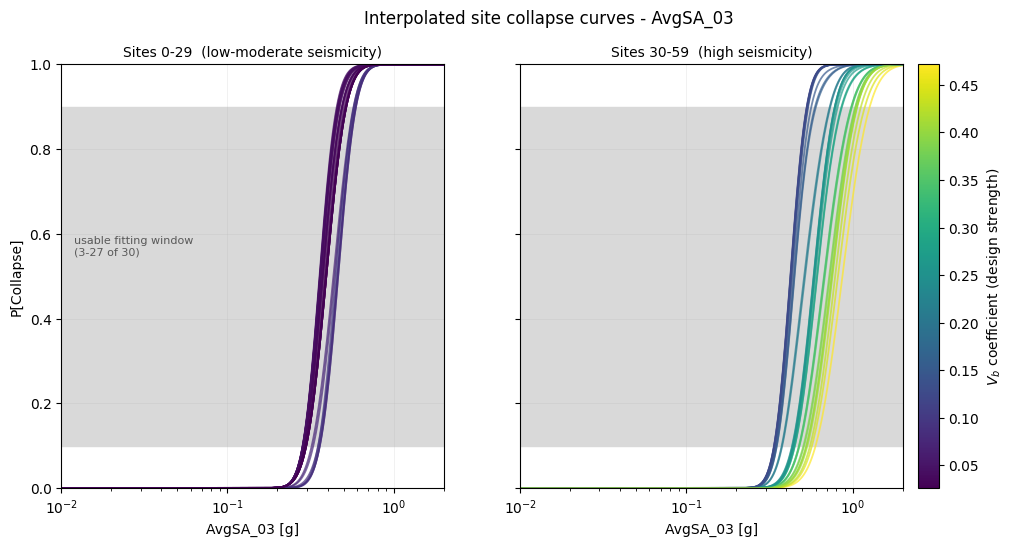

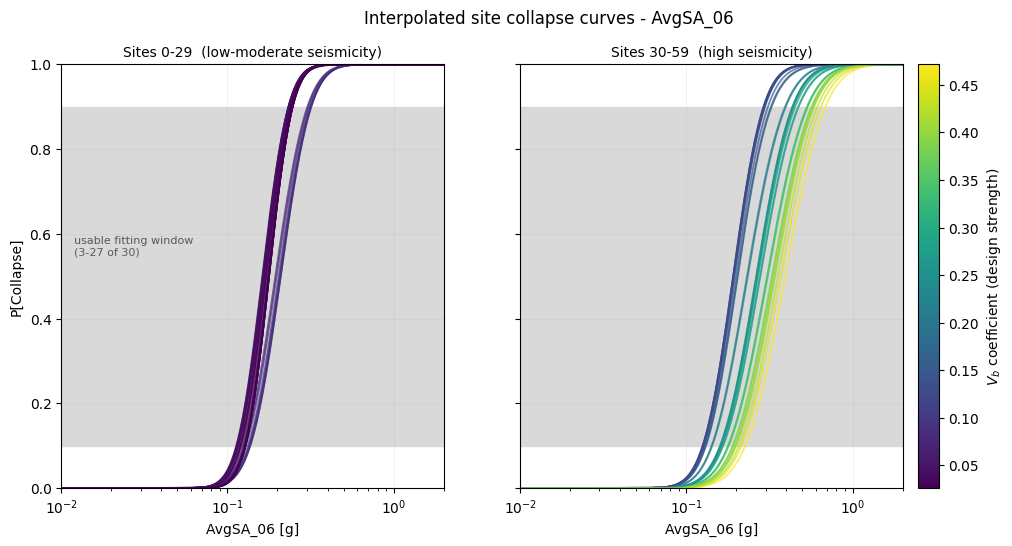

In [171]:
CMAP = plt.get_cmap("viridis")  # sequential: Vb_coeff is a magnitude
NORM = Normalize(vmin=site_vb.min(), vmax=site_vb.max())


def plot_site_collapse_curves(im):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True, sharex=True)
    for ax, (site_range, title) in zip(axes, GROUPS):
        ax.axhspan(LO / N_RECORDS, HI / N_RECORDS, color="0.85", zorder=0)
        for site in site_range:
            ax.plot(IML_GRID, site_fcs[im][site], color=CMAP(NORM(site_vb[site])), lw=1.3, alpha=0.7)
        ax.set_xscale("log")
        ax.set_xlim(0.01, 2.0)
        ax.set_ylim(0, 1)
        ax.set_xlabel(f"{im} [g]")
        ax.set_title(title, fontsize=10)
        ax.grid(alpha=0.25, lw=0.5)
    axes[0].set_ylabel("P[Collapse]")
    axes[0].text(0.012, 0.55, f"usable fitting window\n({LO}-{HI} of {N_RECORDS})", fontsize=8, color="0.35")
    cbar = fig.colorbar(ScalarMappable(norm=NORM, cmap=CMAP), ax=axes, pad=0.015)
    cbar.set_label("$V_b$ coefficient (design strength)")
    fig.suptitle(f"Interpolated site collapse curves - {im}", fontsize=12)
    plt.show()


for im in IMS:
    plot_site_collapse_curves(im)

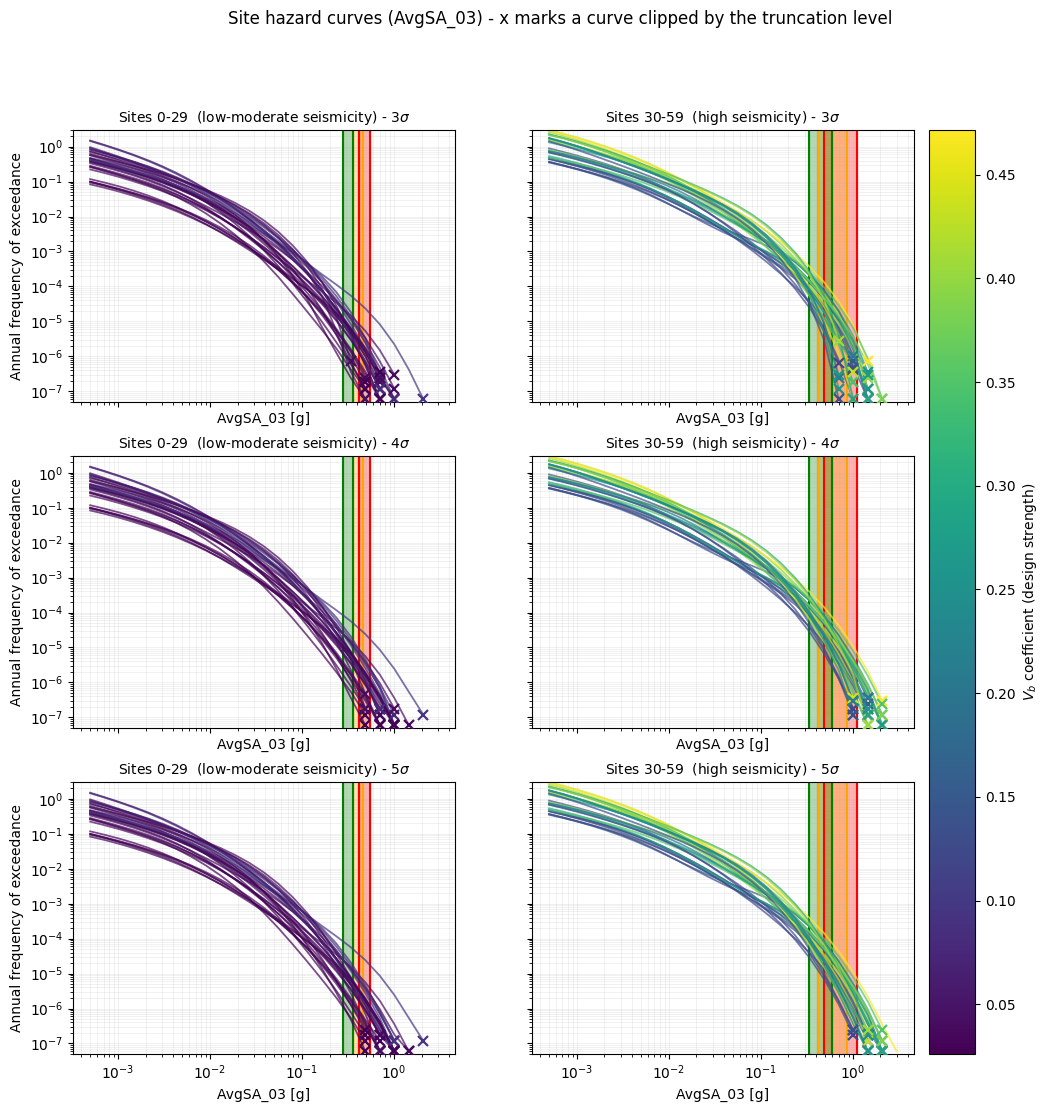

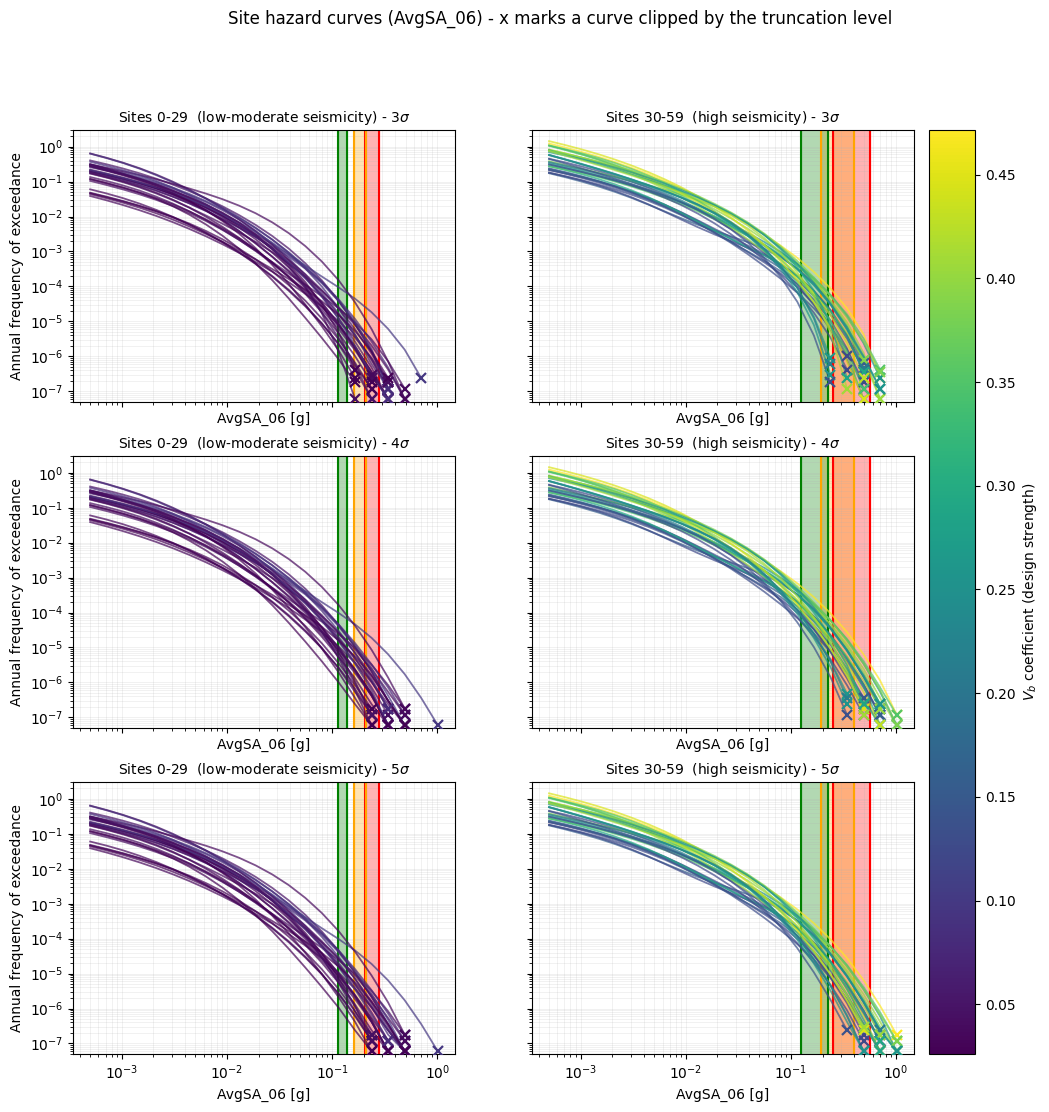

In [172]:
def pc_iml_bounds(im, site_range, p):
    """[min, max] IML (g) at which P[C] = p across the sites in a group."""
    vals = [np.interp(p, site_fcs[im][s], IML_GRID) for s in site_range]
    return [min(vals), max(vals)]


def plot_hazard_with_windows(im):
    """Site hazard curves at 3/4/5 sigma with the P[C] = 10/50/80% IML windows overlaid."""
    fig, axes = plt.subplots(3, 2, figsize=(13, 12), sharey=True, sharex=True)
    y1, y2 = 3e-8, 4
    for ii, level in enumerate(TRUNC_LEVELS):
        for jj, (site_range, title) in enumerate(GROUPS):
            ax = axes[ii, jj]
            for p, colour in zip((0.8, 0.5, 0.1), ("r", "orange", "g")):
                lo, hi = pc_iml_bounds(im, site_range, p)
                ax.fill_betweenx([y1, y2], lo, hi, color=colour, alpha=0.3)
                ax.vlines([lo, hi], y1, y2, color=colour)
            for site in site_range:
                hc = hazard[im][level][site]
                iml, mafe = hc[:, 0], hc[:, 1]
                pos = mafe > 0  # log axis: drop the non-positive tail
                ax.plot(iml[pos], mafe[pos], color=CMAP(NORM(site_vb[site])), lw=1.3, alpha=0.7)
                if not pos.all():  # curve clipped by the truncation level -> flag last point
                    last = np.flatnonzero(pos)[-1]
                    ax.plot(iml[last], mafe[last], ls="none", marker="x", ms=7,
                            mec=CMAP(NORM(site_vb[site])), mew=1.6, zorder=3)
            ax.set_xscale("log")
            ax.set_yscale("log")
            ax.set_xlabel(f"{im} [g]")
            ax.set_title(rf"{title} - {level}$\sigma$", fontsize=10)
            ax.grid(alpha=0.25, which="both", lw=0.5)
    for ax in axes[:, 0]:
        ax.set_ylabel("Annual frequency of exceedance")
        ax.set_ylim(5e-8, 3)
    cbar = fig.colorbar(ScalarMappable(norm=NORM, cmap=CMAP), ax=axes, pad=0.015)
    cbar.set_label("$V_b$ coefficient (design strength)")
    fig.suptitle(f"Site hazard curves ({im}) - x marks a curve clipped by the truncation level", fontsize=12)
    plt.show()


for im in IMS:
    plot_hazard_with_windows(im)

## 4. Select disaggregation IMLs (compared across truncation levels)

For each site the selection runs in three steps: (1) find the **ideal** match of the target
P[C]s over the full grid (the IMLs we would pick with unlimited hazard); (2) find the
**considerable** IMLs — those grid points at or below the hazard ceiling (the largest IML
with positive MAFE) for that truncation level; (3) run the Hungarian match **again over only
the considerable IMLs** to get the **selected** set. Re-matching over the reachable IMLs
(rather than matching over the full grid and then discarding out-of-reach points) ensures a
usable IML is never skipped just because a lower ideal match was truncated away.

Because the ceiling grows with σ, the selection is repeated for σ = 3/4/5 and compared: the
table reports, per (IM, σ), how many sites keep all 4 IMLs and which fall short (a site is
short only when fewer than 4 grid IMLs are reachable). Use it to confirm `DISAGG_SIGMA`
before writing the outputs in section 5. The example plots show the ideal (red) vs selected
(green) IMLs against each site's interpolated fragility.

In [173]:
def find_closest_unique_matches(targets, options):
    """Closest unique option per target via the Hungarian algorithm (min total |diff|).

    On a rectangular cost matrix scipy returns min(n_targets, n_options) matches, so with
    fewer options than targets every option is used once and the extra targets go unmatched.
    """
    t = np.asarray(targets)[:, None]
    o = np.asarray(options)[None, :]
    _, col_ind = linear_sum_assignment(np.abs(t - o))
    return [options[c] for c in col_ind], col_ind


def max_usable_iml(hc):
    """Largest IML with strictly positive MAFE (the truncation ceiling)."""
    nonpos = np.where(hc[:, 1] <= 0.0)[0]
    return hc[nonpos[0] - 1, 0] if len(nonpos) else hc[-1, 0]


def select_imls(im, sigma):
    """Per-site IML selection at one truncation level.

    Three steps: (1) the *ideal* match of TARGET_PCS over the whole grid (what we would pick
    with unlimited hazard); (2) the *considerable* IMLs = grid points at or below the hazard
    ceiling at this sigma; (3) the *selected* IMLs = the match run again over only the
    considerable IMLs. Matching over the reachable set (rather than matching over the full
    grid and then dropping out-of-reach points) means a usable IML is never skipped just
    because a lower ideal match was truncated away.

    Returns {site: {ideal_imls, iml_max, selected_imls, n_good}}, IMLs ascending.
    """
    grid = IMLS[im]
    out = {}
    for site in sites:
        pcs = np.interp(grid, IML_GRID, site_fcs[im][site])   # P[C] at each grid IML

        # 1. ideal: best matches over the full grid (reference only)
        _, ideal_idxs = find_closest_unique_matches(TARGET_PCS, pcs)
        ideal_imls = grid[np.sort(ideal_idxs)]

        # 2. considerable: grid IMLs at/below the truncation ceiling
        iml_max = max_usable_iml(hazard[im][sigma][site])
        mask = grid <= iml_max

        # 3. selected: re-match over only the considerable IMLs
        if mask.any():
            _, sel_idxs = find_closest_unique_matches(TARGET_PCS, pcs[mask])
            selected = np.sort(grid[mask][sel_idxs])
        else:
            selected = np.array([])

        out[site] = {
            "ideal_imls": ideal_imls,
            "iml_max": iml_max,
            "selected_imls": selected,
            "n_good": int(len(selected)),
        }
    return out


selection = {im: {sigma: select_imls(im, sigma) for sigma in TRUNC_LEVELS} for im in IMS}

In [174]:
# Comparison across truncation levels: how many of the (up to 4) suitable IMLs survive the
# hazard ceiling at each sigma, per IM. Use this to pick DISAGG_SIGMA.
rows = []
for im in IMS:
    for sigma in TRUNC_LEVELS:
        sel = selection[im][sigma]
        n_good = np.array([sel[s]["n_good"] for s in sites])
        rows.append({
            "IM": im,
            "sigma": sigma,
            "sites_with_4": int((n_good == 4).sum()),
            "sites_with_3": int((n_good == 3).sum()),
            "sites_with_<=2": int((n_good <= 2).sum()),
            "flagged_<4": [s for s in sites if sel[s]["n_good"] < 4],
        })
comparison = pd.DataFrame(rows)
comparison

,IM,sigma,sites_with_4,sites_with_3,sites_with_<=2,flagged_<4
0,AvgSA_03,3,59,1,0,[22]
1,AvgSA_03,4,60,0,0,[]
2,AvgSA_03,5,60,0,0,[]
3,AvgSA_06,3,56,0,4,"[8, 19, 22, 27]"
4,AvgSA_06,4,60,0,0,[]
5,AvgSA_06,5,60,0,0,[]


AvgSA_03 site with fewest usable IMLs at 4 sigma: site 0 (4 IMLs)


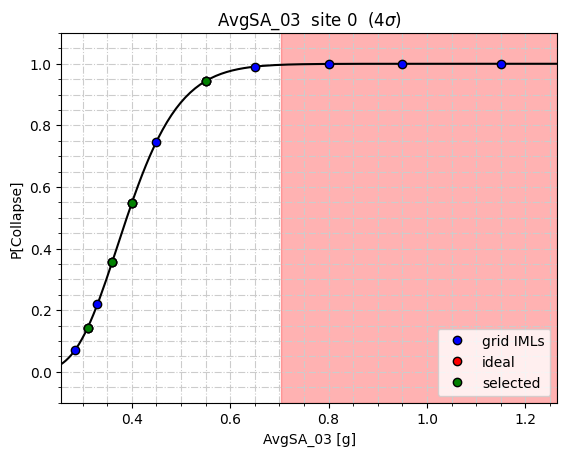

In [175]:
def plot_site_selection(im, site, sigma=DISAGG_SIGMA):
    """Interpolated fragility for one site with its grid / ideal / selected IMLs marked."""
    sel = selection[im][sigma][site]
    grid = IMLS[im]
    fc = site_fcs[im][site]

    def pc(x):
        return np.interp(x, IML_GRID, fc)

    fig, ax = plt.subplots()
    ax.plot(IML_GRID, fc, color="k")
    ax.plot(grid, pc(grid), ls="", marker="o", mfc="b", mec="k", label="grid IMLs")
    ax.plot(sel["ideal_imls"], pc(sel["ideal_imls"]), ls="", marker="o", mfc="r", mec="k", label="ideal")
    ax.plot(sel["selected_imls"], pc(sel["selected_imls"]), ls="", marker="o", mfc="g", mec="k", label="selected")
    ax.fill_betweenx([-0.1, 1.1], sel["iml_max"], grid[-1] * 1.1, color="r", alpha=0.3)
    ax.set_xlim(grid[0] * 0.9, grid[-1] * 1.1)
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlabel(f"{im} [g]")
    ax.set_ylabel("P[Collapse]")
    ax.set_title(rf"{im}  site {site}  ({sigma}$\sigma$)")
    ax.grid(which="both", ls="-.", color="0.8")
    ax.minorticks_on()
    ax.legend()
    plt.show()


# Example: the AvgSA_03 site with the fewest usable IMLs at the chosen truncation level.
worst = min(sites, key=lambda s: selection["AvgSA_03"][DISAGG_SIGMA][s]["n_good"])
print(f"AvgSA_03 site with fewest usable IMLs at {DISAGG_SIGMA} sigma: site {worst} "
      f"({selection['AvgSA_03'][DISAGG_SIGMA][worst]['n_good']} IMLs)")
plot_site_selection("AvgSA_03", worst)

AvgSA_06 site with fewest usable IMLs at 4 sigma: site 0 (4 IMLs)


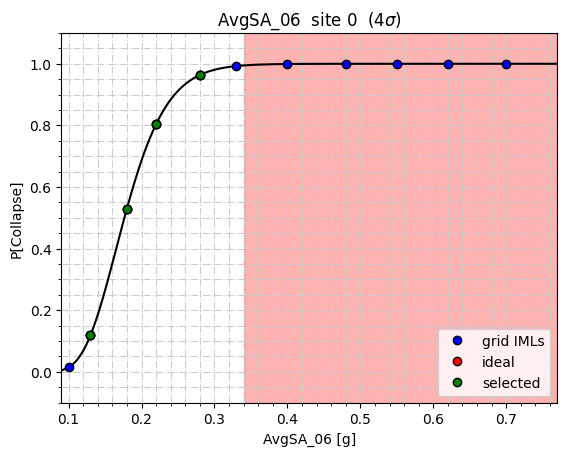

In [176]:
# Example: the AvgSA_06 site with the fewest usable IMLs at the chosen truncation level.
worst_06 = min(sites, key=lambda s: selection["AvgSA_06"][DISAGG_SIGMA][s]["n_good"])
print(f"AvgSA_06 site with fewest usable IMLs at {DISAGG_SIGMA} sigma: site {worst_06} "
      f"({selection['AvgSA_06'][DISAGG_SIGMA][worst_06]['n_good']} IMLs)")
plot_site_selection("AvgSA_06", worst_06)

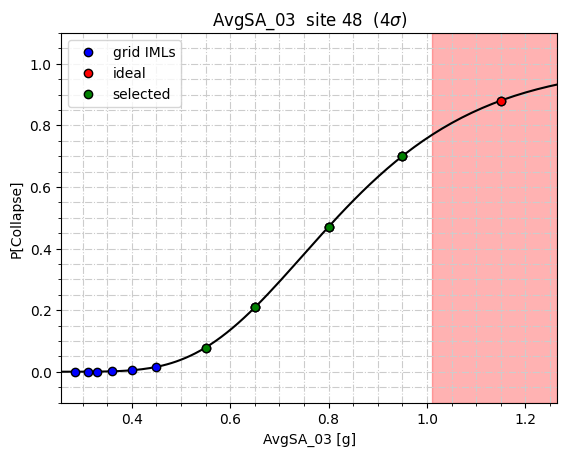

In [199]:
# --- Manual site check: edit IM_CHECK / SITE_CHECK / SIGMA_CHECK to inspect any site by hand ---
IM_CHECK = "AvgSA_03"
SITE_CHECK = 48
SIGMA_CHECK = 4  # one of TRUNC_LEVELS (3, 4, 5)
plot_site_selection(IM_CHECK, SITE_CHECK, sigma=SIGMA_CHECK)

Some examples of interesting sites to look at are 22, 38, 49, 48 (AvgSA_03)

## 5. Write outputs

Two artefacts per IM, at the chosen truncation level `DISAGG_SIGMA`:

1. **Flat disaggregation IML grid** → `cfg["proc_data"]["disagg_imls_AvgSA_0{3,6}"]`
   (`np.savetxt`), the full grid OpenQuake disaggregates at (nb 020/021).
2. **Per-site record-selection stripes** → `cfg["proc_data"]["AvgSA_0{3,6}_imls_for_selection"]`,
   JSON `{site_id: [imls]}`. Each list is the (≤4) suitable IMLs plus one grid step **below**
   and one **above**, sorted ascending. The upper (and, rarely, lower) neighbour is `null`
   when it does not exist on the grid or exceeds the hazard ceiling — `null` loads back as
   `None`, which the record-selection setup scripts skip.

In [178]:
def build_per_site_imls(im, sigma):
    """Per-site record-selection stripes: the selected IMLs plus one grid step below and one
    above, ascending. Missing neighbours become None (JSON null)."""
    grid = list(IMLS[im])
    result = {}
    for site in sites:
        sel = selection[im][sigma][site]
        chosen = [float(x) for x in sel["selected_imls"]]
        if not chosen:
            result[str(site)] = []  # nothing usable (does not occur for the current grids)
            continue
        lo_i = grid.index(min(chosen))
        hi_i = grid.index(max(chosen))
        lower = grid[lo_i - 1] if lo_i - 1 >= 0 else None
        upper = grid[hi_i + 1] if (hi_i + 1 < len(grid) and grid[hi_i + 1] <= sel["iml_max"]) else None
        stripe = [lower] + chosen + [upper]  # already ascending; ends may be None
        result[str(site)] = [round(float(x), 4) if x is not None else None for x in stripe]
    return result


def write_outputs(sigma=DISAGG_SIGMA):
    for im in IMS:
        # 1. flat disaggregation IML grid (nb 020/021)
        grid_fp = cfg["proc_data"][f"disagg_imls_{im}"]
        np.savetxt(grid_fp, IMLS[im], delimiter=",")
        print(f"wrote {grid_fp.name}  ({len(IMLS[im])} IMLs)")

        # 2. per-site record-selection stripes (nb 031-036)
        per_site = build_per_site_imls(im, sigma)
        sel_fp = cfg["proc_data"][f"{im}_imls_for_selection"]
        with open(sel_fp, "w") as f:
            json.dump(per_site, f, indent=4)
        n_null = sum(1 for v in per_site.values() if None in v)
        print(f"wrote {sel_fp.name}  ({len(per_site)} sites, {n_null} with a null upper stripe)")


write_outputs(DISAGG_SIGMA)

wrote AvgSA_03_imls_for_disaggregation.csv  (11 IMLs)
wrote imls_for_selection_AvgSA_03.json  (60 sites, 16 with a null upper stripe)
wrote AvgSA_06_imls_for_disaggregation.csv  (11 IMLs)
wrote imls_for_selection_AvgSA_06.json  (60 sites, 25 with a null upper stripe)


## 6. Summary
4 $\sigma$ offers the best balance between the a sensible truncation limit and allowing strong enough hazard to select stripes that are useful for fragility curve fitting. For this reason I will continue the rest of this work using a 4 $\sigma$ hazard and I will perform the disaggregation at the 4 $\sigma$ level. 3 $\sigma$ and 5 $\sigma$ won't play any further role.